# Hourly Time Series Forecasting using Facebook's Prophet
![](https://miro.medium.com/max/964/0*tVCene42rgUTNv9Q.png)

In this notebook we will use facebook's prophet package to forecast hourly energy use.

# Background on the Types of Time Series Data
![img](https://miro.medium.com/max/1400/1*V_RKPeIxCB9CS_2SsLyKXw.jpeg)

In [ ]:
!pip install prophet

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from prophet import Prophet

from sklearn.metrics import mean_squared_error, mean_absolute_error

import warnings
warnings.filterwarnings("ignore")

plt.style.use('ggplot')
plt.style.use('fivethirtyeight')

def mean_absolute_percentage_error(y_true, y_pred):
    """Calculates MAPE given y_true and y_pred"""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Data
The data we will be using is hourly power consumption data from PJM. Energy consumption has some unique characteristics. It will be interesting to see how prophet picks them up.

Pulling the `PJM East` which has data from 2002-2018 for the entire east region.


In [ ]:
df = pd.read_csv('/content/processed_sales.csv',
                   index_col=[0],
                  parse_dates=[0])
df.head()

,y,is_holiday
ds,,
2015-01-03,16.448,1
2015-01-04,288.060,0
2015-01-05,19.536,0
2015-01-06,4407.100,0
2015-01-07,87.158,0


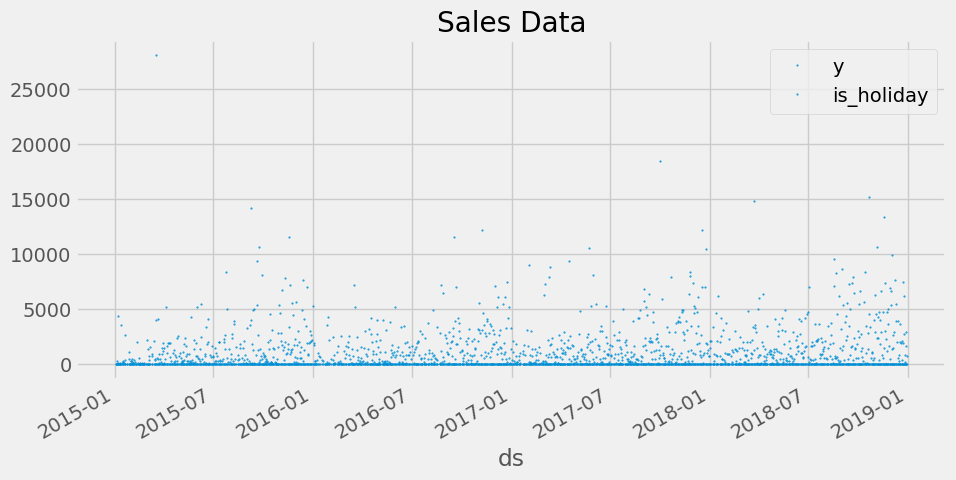

In [ ]:
color_pal = sns.color_palette()
df.plot(style='.',
          figsize=(10, 5),
          ms=1,
          color=color_pal[0],
          title='Sales Data')
plt.show()

# Time Series Features

In [ ]:
from pandas.api.types import CategoricalDtype

cat_type = CategoricalDtype(categories=['Monday','Tuesday',
                                        'Wednesday',
                                        'Thursday','Friday',
                                        'Saturday','Sunday'],
                            ordered=True)

def create_features(df, label=None):
    """
    Creates time series features from datetime index.
    """
    df = df.copy()
    df['date'] = df.index
    df['hour'] = df['date'].dt.hour
    df['dayofweek'] = df['date'].dt.dayofweek
    df['weekday'] = df['date'].dt.day_name()
    df['weekday'] = df['weekday'].astype(cat_type)
    df['quarter'] = df['date'].dt.quarter
    df['month'] = df['date'].dt.month
    df['year'] = df['date'].dt.year
    df['dayofyear'] = df['date'].dt.dayofyear
    df['dayofmonth'] = df['date'].dt.day
    df['weekofyear'] = df['date'].dt.isocalendar().week.astype(int)
    df['date_offset'] = (df.date.dt.month*100 + df.date.dt.day - 320)%1300

    df['season'] = pd.cut(df['date_offset'], [0, 300, 602, 900, 1300],
                          labels=['Spring', 'Summer', 'Fall', 'Winter']
                   )
    X = df[['hour','dayofweek','quarter','month','year',
           'dayofyear','dayofmonth','weekofyear','weekday',
           'season']]
    if label:
        y = df[label]
        return X, y
    return X

X, y = create_features(df, label='y')
features_and_target = pd.concat([X, y], axis=1)

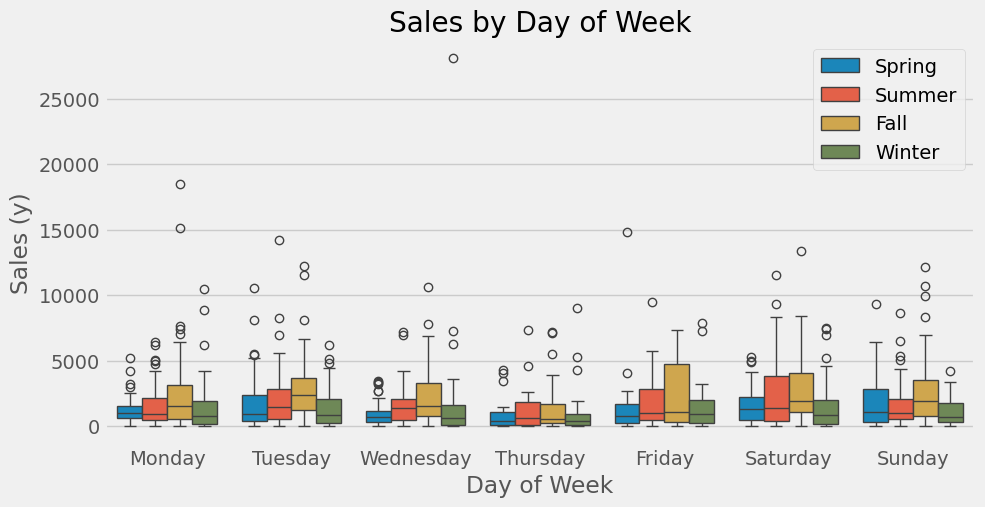

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=features_and_target.dropna(),
            x='weekday',
            y='y',
            hue='season',
            ax=ax,
            linewidth=1)
ax.set_title('Sales by Day of Week')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Sales (y)')
ax.legend(bbox_to_anchor=(1, 1))
plt.show()

# Train / Test Split

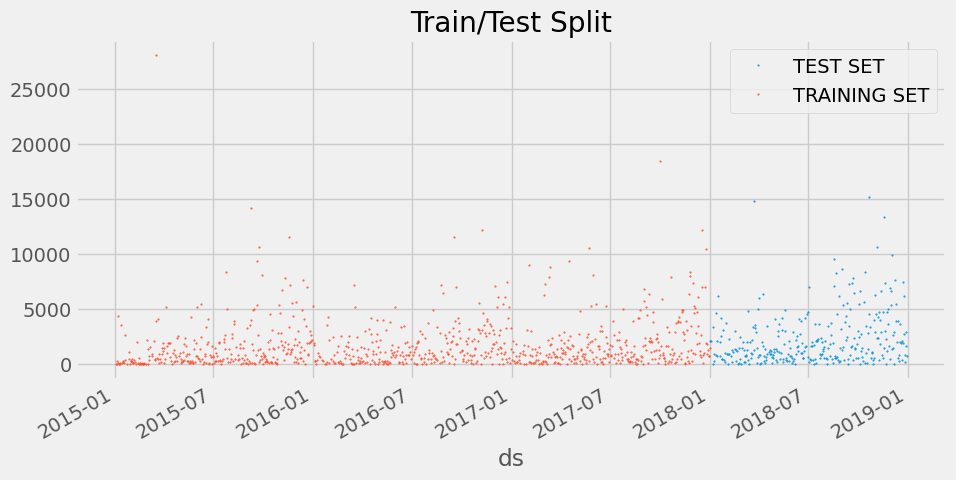

In [ ]:
split_date = '2018-01-01'
df_train = df.loc[df.index <= split_date].copy()
df_test = df.loc[df.index > split_date].copy()

# Plot train and test - selecting only 'y' column to avoid overlap errors
df_test[['y']] \
    .rename(columns={'y': 'TEST SET'}) \
    .join(df_train[['y']].rename(columns={'y': 'TRAINING SET'}),
          how='outer') \
    .plot(figsize=(10, 5), title='Train/Test Split', style='.', ms=1)
plt.show()

# Simple Prophet Model
- Prophet model expects the dataset to be named a specific way. We will rename our dataframe columns before feeding it into the model.
    - Datetime column named: `ds`
    - target : `y`

In [ ]:
# Format data for prophet model using ds and y
df_train_prophet = df_train.reset_index() \
    .rename(columns={'ds':'ds',
                     'y':'y'})
# Note: If your index was already 'ds', reset_index() handles it.

In [ ]:
%%time
model = Prophet()
model.fit(df_train_prophet)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


CPU times: user 96.8 ms, sys: 2.85 ms, total: 99.6 ms
Wall time: 138 ms


In [ ]:
# Predict on test set with model
df_test_prophet = df_test.reset_index() \
    .rename(columns={'ds':'ds',
                     'y':'y'})

df_test_fcst = model.predict(df_test_prophet)

In [ ]:
df_test_fcst.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2018-01-02,1876.788035,-866.595682,4738.415824,1876.788035,1876.788035,145.692633,145.692633,145.692633,339.569417,339.569417,339.569417,-193.876784,-193.876784,-193.876784,0.0,0.0,0.0,2022.480668
1,2018-01-03,1877.432068,-999.195263,4478.435785,1877.432068,1877.432068,-154.744081,-154.744081,-154.744081,188.044717,188.044717,188.044717,-342.788798,-342.788798,-342.788798,0.0,0.0,0.0,1722.687987
2,2018-01-06,1879.364166,-1392.183389,3873.834538,1879.364166,1879.364166,-466.062371,-466.062371,-466.062371,276.100929,276.100929,276.100929,-742.163301,-742.163301,-742.163301,0.0,0.0,0.0,1413.301795
3,2018-01-07,1880.008199,-1630.981841,3778.888821,1880.008199,1880.008199,-770.109490,-770.109490,-770.109490,82.384123,82.384123,82.384123,-852.493613,-852.493613,-852.493613,0.0,0.0,0.0,1109.898708
4,2018-01-08,1880.652231,-1677.367853,3651.763320,1880.652231,1880.652231,-1008.656391,-1008.656391,-1008.656391,-60.139278,-60.139278,-60.139278,-948.517113,-948.517113,-948.517113,0.0,0.0,0.0,871.995840


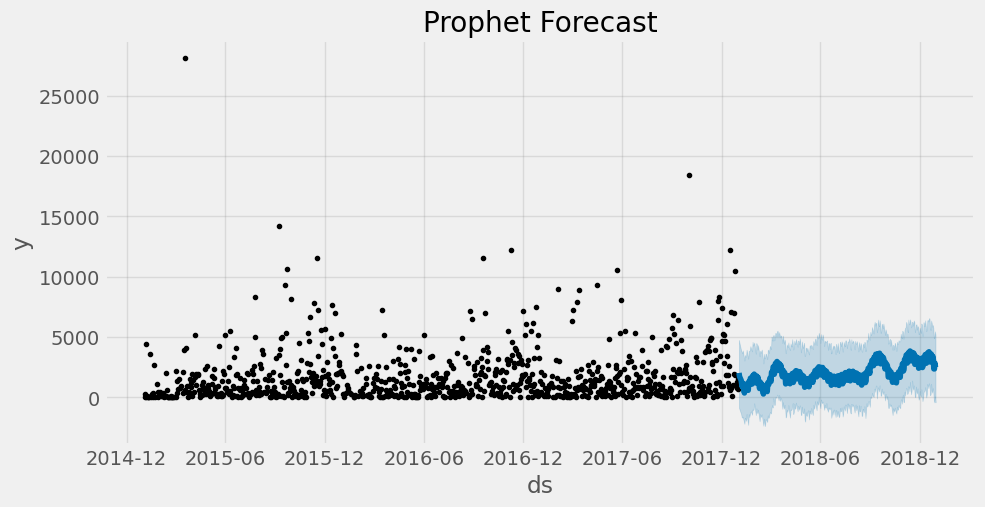

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
fig = model.plot(df_test_fcst, ax=ax)
ax.set_title('Prophet Forecast')
plt.show()

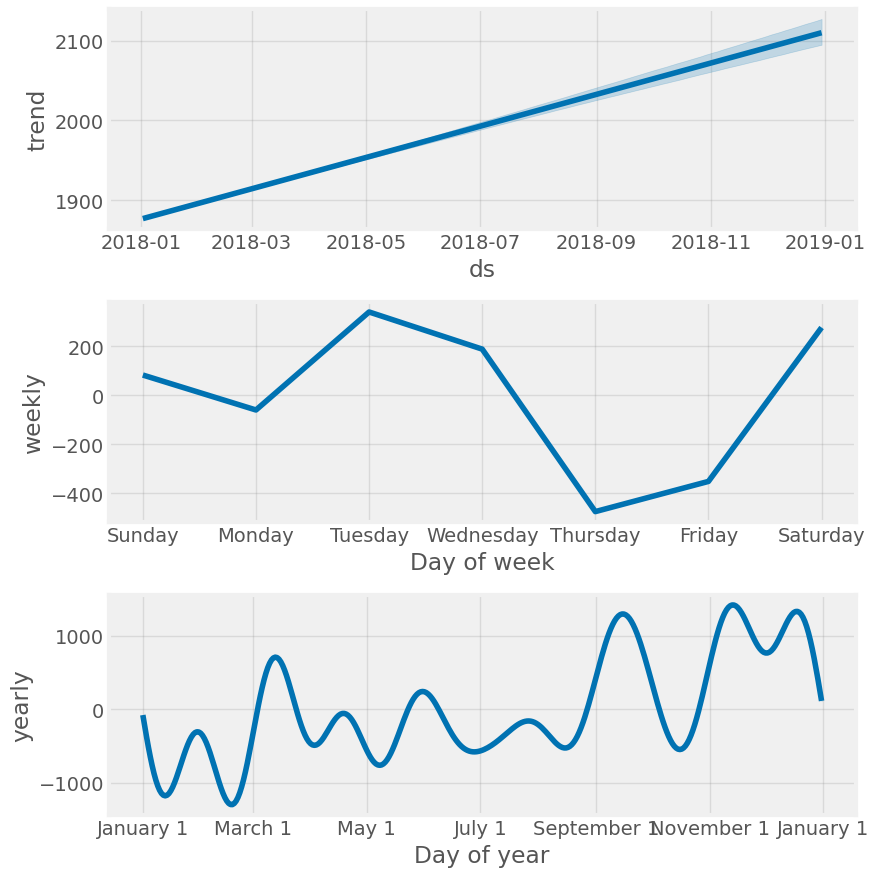

In [ ]:
fig = model.plot_components(df_test_fcst)
plt.show()

# Compare Forecast to Actuals

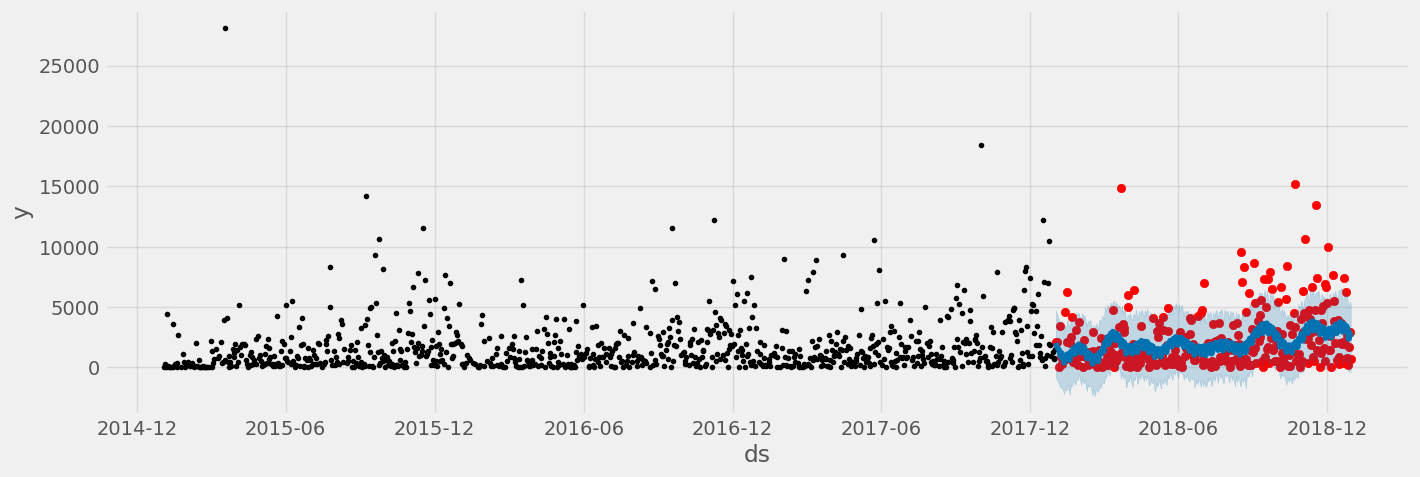

In [ ]:
# Plot the forecast with the actuals
f, ax = plt.subplots(figsize=(15, 5))
ax.scatter(df_test.index, df_test['y'], color='r')
fig = model.plot(df_test_fcst, ax=ax)

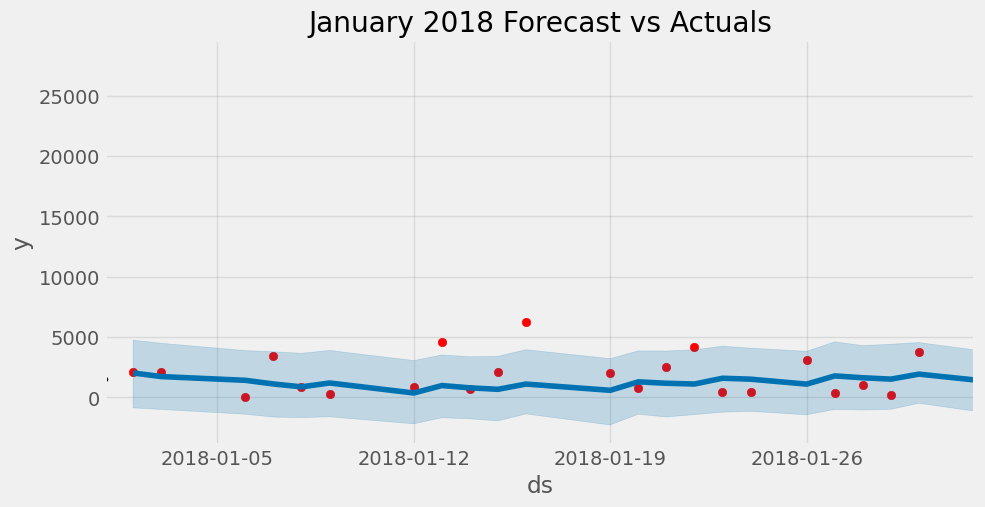

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(df_test.index, df_test['y'], color='r')
fig = model.plot(df_test_fcst, ax=ax)
ax.set_xbound(lower=pd.to_datetime('2018-01-01'),
              upper=pd.to_datetime('2018-02-01'))
ax.set_title('January 2018 Forecast vs Actuals')
plt.show()

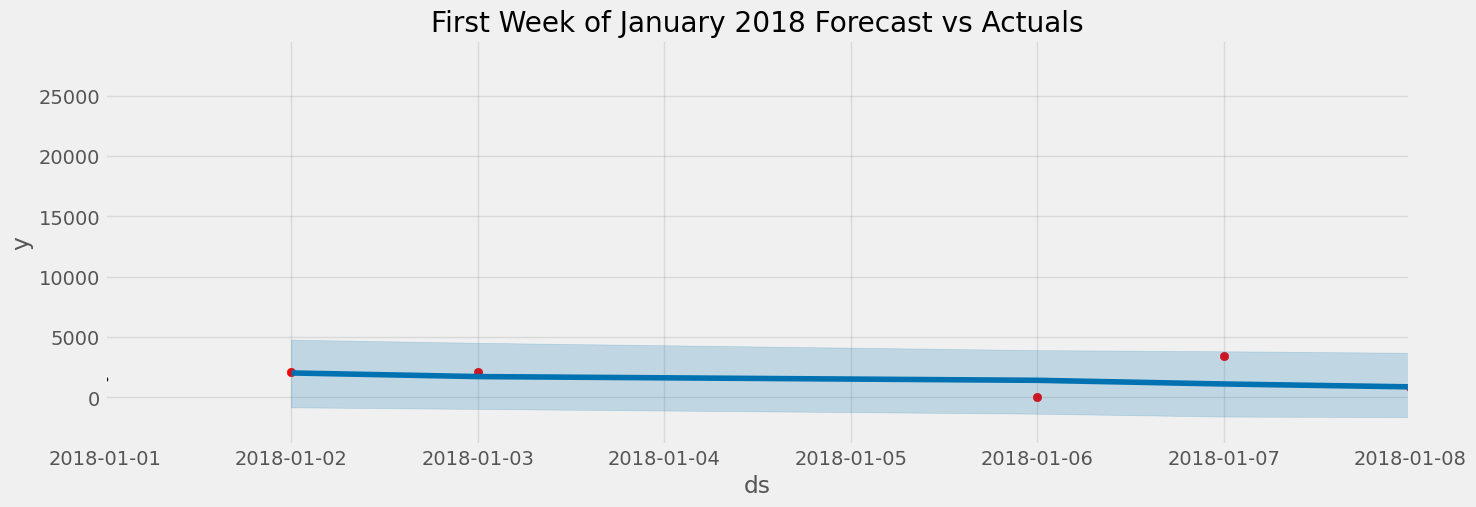

In [ ]:
# Plot the forecast with the actuals for the first week
f, ax = plt.subplots(figsize=(15, 5))
ax.scatter(df_test.index, df_test['y'], color='r')
fig = model.plot(df_test_fcst, ax=ax)
ax.set_xbound(lower=pd.to_datetime('2018-01-01'), upper=pd.to_datetime('2018-01-08'))
ax.set_title('First Week of January 2018 Forecast vs Actuals')
plt.show()

# Evaluate the model with Error Metrics

In [ ]:
np.sqrt(mean_squared_error(y_true=df_test['y'],
                   y_pred=df_test_fcst['yhat']))

np.float64(2332.6684224626165)

In [ ]:
mean_absolute_error(y_true=df_test['y'],
                   y_pred=df_test_fcst['yhat'])

1637.7459153370414

In [ ]:
mean_absolute_percentage_error(y_true=df_test['y'],
                   y_pred=df_test_fcst['yhat'])

np.float64(607.1091576344714)

# Adding Holidays

Next we will see if adding holiday indicators will help the accuracy of the model. Prophet comes with a Holiday Effects parameter that can be provided to the model prior to training.

We will use the built in pandas USFederalHolidayCalendar to pull the list of holidays

In [ ]:
from pandas.tseries.holiday import USFederalHolidayCalendar as calendar

cal = calendar()

holidays = cal.holidays(start=df.index.min(),
                        end=df.index.max(),
                        return_name=True)
holiday_df = pd.DataFrame(data=holidays,
                          columns=['holiday'])
holiday_df = holiday_df.reset_index().rename(columns={'index':'ds'})

In [ ]:
%%time
model_with_holidays = Prophet(holidays=holiday_df)
model_with_holidays.fit(df_train_prophet)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


CPU times: user 94.1 ms, sys: 3.89 ms, total: 98 ms
Wall time: 156 ms


In [ ]:
# Predict on test set with holiday model
df_test_fcst_with_hols = \
    model_with_holidays.predict(df=df_test_prophet)

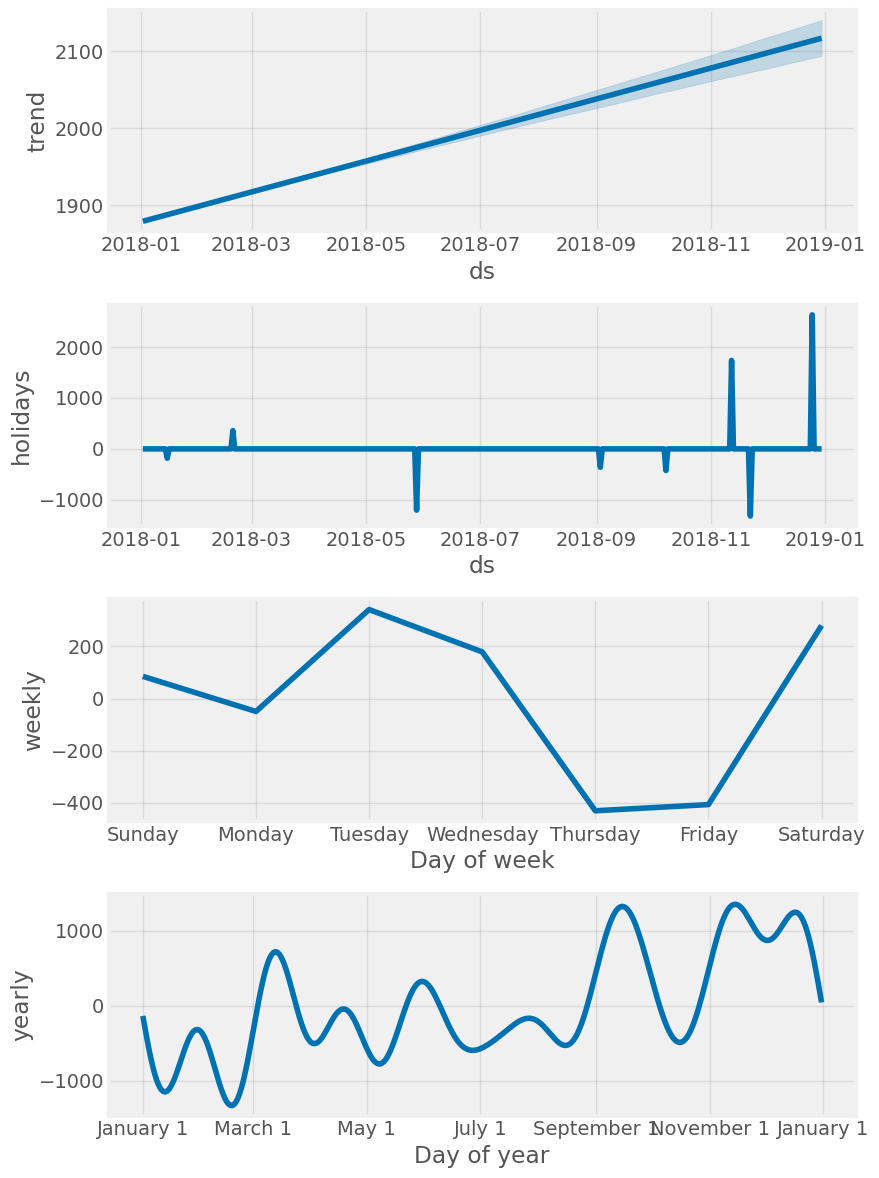

In [ ]:
fig = model_with_holidays.plot_components(
    df_test_fcst_with_hols)
plt.show()

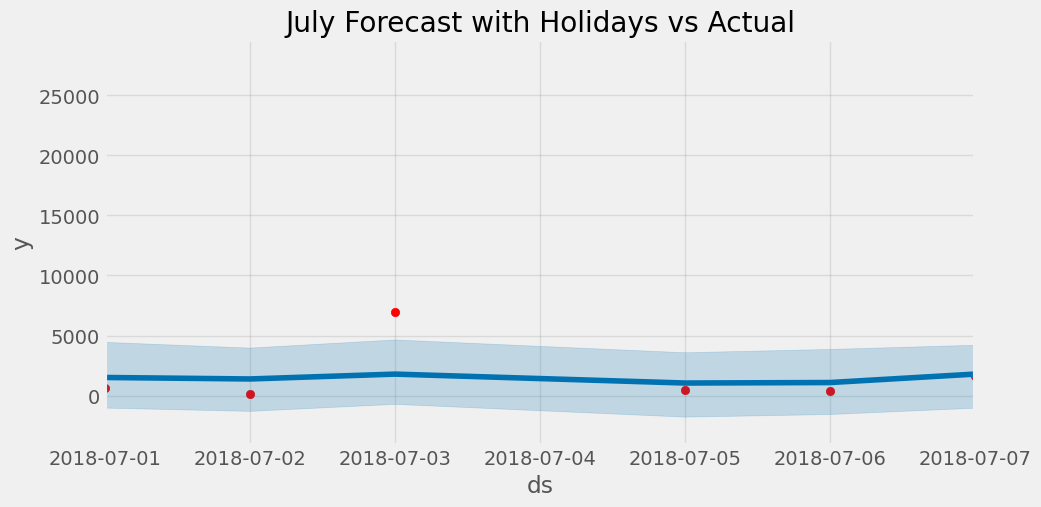

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(df_test.index, df_test['y'], color='r')
fig = model_with_holidays.plot(df_test_fcst_with_hols, ax=ax)
ax.set_xbound(lower=pd.to_datetime('2018-07-01'),
              upper=pd.to_datetime('2018-07-07'))
ax.set_title('July Forecast with Holidays vs Actual')
plt.show()

In [ ]:
np.sqrt(mean_squared_error(y_true=df_test['y'],
                   y_pred=df_test_fcst_with_hols['yhat']))

np.float64(2339.004533000497)

In [ ]:
mean_absolute_error(y_true=df_test['y'],
                   y_pred=df_test_fcst_with_hols['yhat'])

1646.0601979953149

In [ ]:
mean_absolute_percentage_error(y_true=df_test['y'],
                   y_pred=df_test_fcst_with_hols['yhat'])

np.float64(607.7963921708404)

In [ ]:
import pandas as pd
import numpy as np
from prophet import Prophet
from pandas.tseries.holiday import USFederalHolidayCalendar as calendar

# 1. Pastikan data tersedia
try:
    df.head()
except NameError:
    df = pd.read_csv('/content/processed_sales.csv', index_col=[0], parse_dates=[0])

split_date = '2018-01-01'
df_train = df.loc[df.index <= split_date].copy()
df_test = df.loc[df.index > split_date].copy()
df_train_prophet = df_train.reset_index().rename(columns={'ds':'ds', 'y':'y'})
df_test_prophet = df_test.reset_index().rename(columns={'ds':'ds', 'y':'y'})

# 2. Inisialisasi Ulang Model dan Prediksi jika variabel hilang
try:
    model_with_holidays
except NameError:
    cal = calendar()
    hols = cal.holidays(start=df.index.min(), end=df.index.max(), return_name=True)
    holiday_df = pd.DataFrame(data=hols, columns=['holiday']).reset_index().rename(columns={'index':'ds'})
    model_with_holidays = Prophet(holidays=holiday_df)
    model_with_holidays.fit(df_train_prophet)

df_test_fcst_with_hols = model_with_holidays.predict(df=df_test_prophet)

# 3. Analisis perbandingan untuk menjawab pertanyaan user
comparison = pd.DataFrame({
    'Actual': df_test['y'].values,
    'Predicted': df_test_fcst_with_hols['yhat'].values
}, index=df_test.index)

print("Statistik Deskriptif:")
display(comparison.describe())

# Analisis Error
comparison['Error'] = comparison['Actual'] - comparison['Predicted']
comparison['Abs_Percentage_Error'] = (np.abs(comparison['Error']) / (comparison['Actual'] + 1e-6)) * 100

print("\nAnalisis Nilai Ekstrim:")
print(f"Jumlah nilai 0 pada data aktual: {(df_test['y'] == 0).sum()}")
print(f"Nilai minimum pada data aktual: {df_test['y'].min()}")
print(f"Median dari Absolute Percentage Error: {comparison['Abs_Percentage_Error'].median():.2f}%")

print("\nKesimpulan:")
print("Jika Mean Absolute Error (MAE) ribuan sementara ada nilai aktual yang hanya satuan (misal 16.44), maka MAPE pasti akan meledak (>600%).")

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Statistik Deskriptif:


,Actual,Predicted
count,321.000000,321.000000
mean,2244.766951,2087.729875
std,2397.054699,826.624363
min,3.816000,197.578185
25%,579.019000,1514.634291
50%,1448.676000,1928.787193
75%,2997.578000,2667.080181
max,15158.877000,5939.118493



Analisis Nilai Ekstrim:
Jumlah nilai 0 pada data aktual: 0
Nilai minimum pada data aktual: 3.816
Median dari Absolute Percentage Error: 70.38%

Kesimpulan:
Jika Mean Absolute Error (MAE) ribuan sementara ada nilai aktual yang hanya satuan (misal 16.44), maka MAPE pasti akan meledak (>600%).


# Predict into the Future

We can use the built in `make_future_dataframe` method to build our future dataframe and make predictions.

In [ ]:
future = model.make_future_dataframe(periods=365*24, freq='h', include_history=False)
forecast = model_with_holidays.predict(future)

In [ ]:
forecast[['ds','yhat']].head()

,ds,yhat
0,2018-01-01 01:00:00,1191.835566
1,2018-01-01 02:00:00,1200.611823
2,2018-01-01 03:00:00,1210.404960
3,2018-01-01 04:00:00,1221.094035
4,2018-01-01 05:00:00,1232.553956


# The End

Jika kolom kategori (seperti `category` atau `item_type`) tersedia, kita bisa melakukan iterasi untuk melatih model Prophet pada setiap kategori tersebut. Namun, dalam kode yang dijalankan sejauh ini, model hanya dilatih untuk satu target agregat (`y`).